In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [41]:
import warnings
warnings.filterwarnings('ignore')

In [42]:
df = pd.read_csv('/content/insurance.csv')

In [43]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


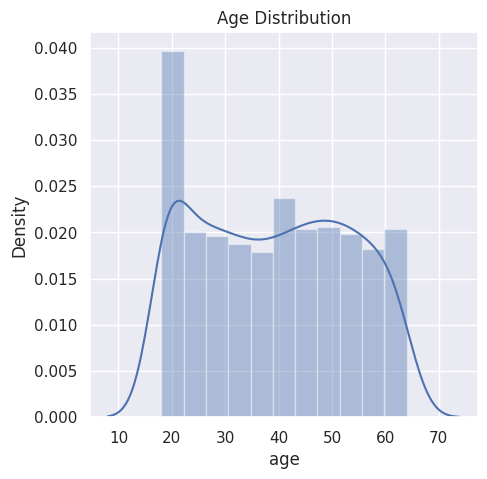

In [46]:
sns.set()
plt.figure(figsize=(5,5))
sns.distplot(df['age'])
plt.title('Age Distribution')
plt.show()

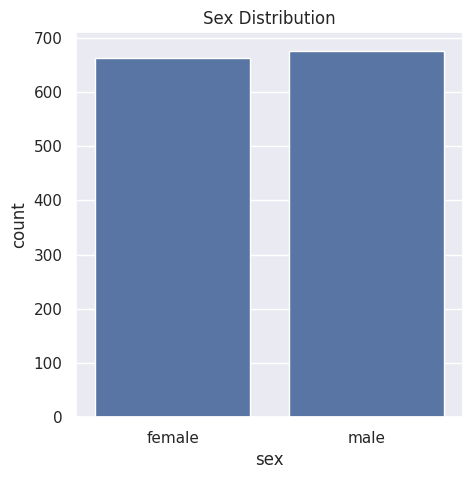

In [47]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'sex', data = df)
plt.title('Sex Distribution')
plt.show()

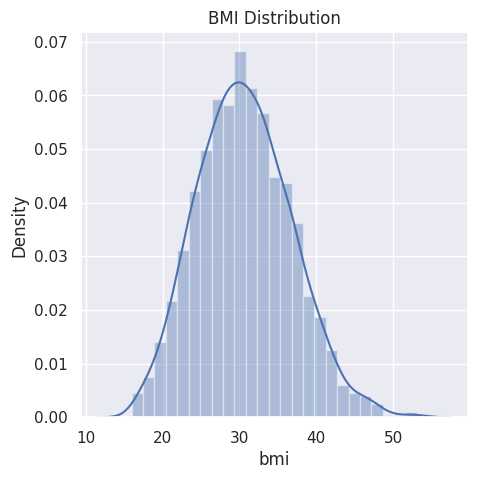

In [48]:
plt.figure(figsize=(5,5))
sns.distplot(df['bmi'])
plt.title('BMI Distribution')
plt.show()

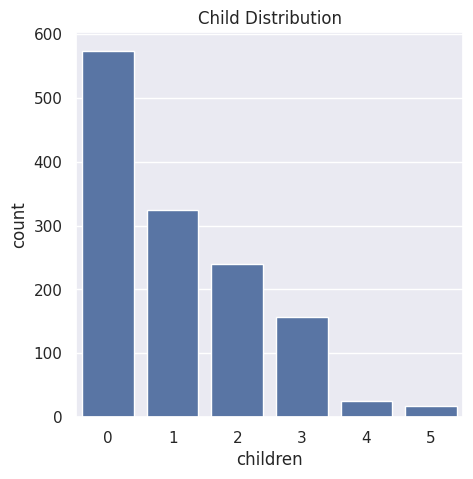

In [49]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'children', data = df)
plt.title('Child Distribution')
plt.show()

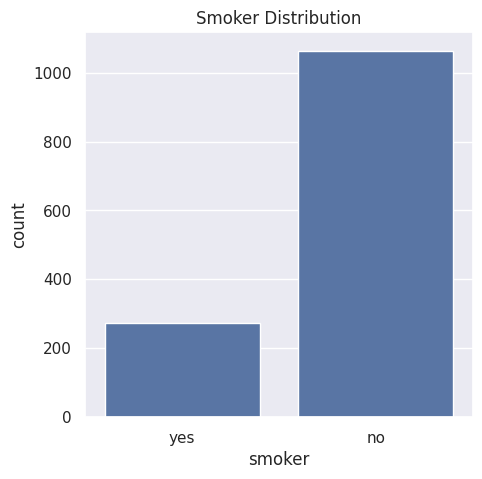

In [50]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'smoker', data = df)
plt.title('Smoker Distribution')
plt.show()

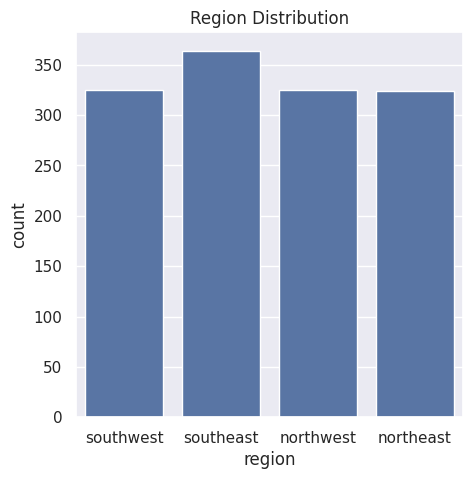

In [51]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'region', data = df)
plt.title('Region Distribution')
plt.show()

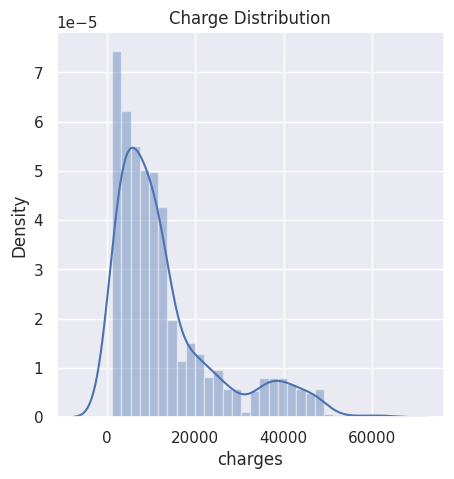

In [52]:
plt.figure(figsize=(5,5))
sns.distplot(df['charges'])
plt.title('Charge Distribution')
plt.show()

In [53]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [55]:
X = df.drop('charges', axis = 1)
y = df['charges']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [57]:
model = LinearRegression()

In [58]:
model.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred = model.predict(X_test)

In [60]:
r2_score = metrics.r2_score(y_test, y_pred)
r2_score

0.7602640802497018

In [61]:
model.score(X_test, y_test)

0.7602640802497018

In [62]:
input_data = (32,1,25,74,0,1)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ',prediction[0])

[32024.2841513]
The insurance cost is USD  32024.284151304877
